In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [5]:
PROJECT_ROOT = Path.cwd().parent
train_path = PROJECT_ROOT / "all_datasets" / "bike_sharing_dataset" / "day.csv"
df = pd.read_csv(train_path)
df["dteday"] = pd.to_datetime(df["dteday"])
df = df.sort_values("dteday").reset_index(drop=True)

In [6]:
# cnt = casual + registered, so casual and registered would leak the target.
features = [
    "season", "yr", "mnth", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed",
]
X = df[features]
y = df["cnt"]

In [7]:
# Chronological development holdout: earlier dates train, later dates validate.
cut = int(len(df) * 0.80)
X_train, X_valid = X.iloc[:cut], X.iloc[cut:]
y_train, y_valid = y.iloc[:cut], y.iloc[cut:]
dates_valid = df["dteday"].iloc[cut:]

cat_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
num_cols = ["temp", "atemp", "hum", "windspeed"]
preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])
model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1
    )),
])
model.fit(X_train, y_train)
pred = model.predict(X_valid)

print("MAE:", round(mean_absolute_error(y_valid, pred), 1))
print("RMSE:", round(np.sqrt(mean_squared_error(y_valid, pred)), 1))

MAE: 1040.4
RMSE: 1245.0


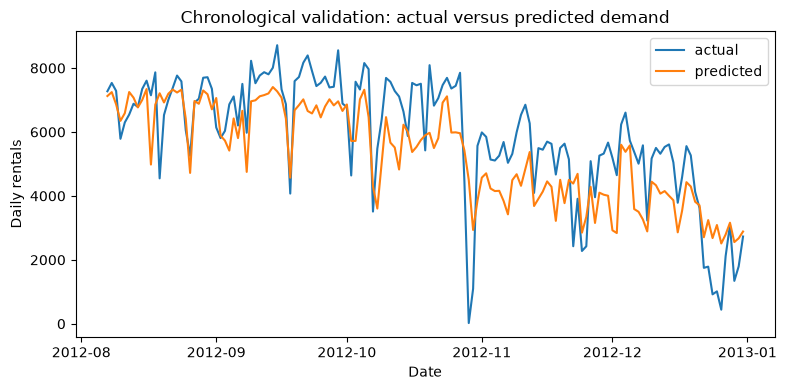

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(dates_valid, y_valid.to_numpy(), label="actual")
plt.plot(dates_valid, pred, label="predicted")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.title("Chronological validation: actual versus predicted demand")
plt.legend()
plt.tight_layout()
plt.show()